In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy
import os

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

W0513 23:40:23.557902 139795885434688 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


## set models parameters

In [3]:
######## Parameters
nb_of_bands = 6
batch_size = 256

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

## Load data

In [4]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_24.5_v2/' # mag cut at 24.5 in r band
#root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_26.5/' # mag cut at 26.5 in r band

In [5]:
images = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c') # artificial augmentation of pixel intensity. Residual from tests, needs to be suppressed
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

## Loading VAE or deblender

In [6]:
#sys.path.insert(0,'../../../Deblender_VAE/scripts/tools_for_VAE/')
sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE
import tools_for_VAE.generator as generator
import tools_for_VAE.utils as utils
import tools_for_VAE.vae_functions as vae_functions

In [7]:

path_output = '/pbs/home/b/barcelin/sps_link/TFP/weights/test_dc2/v19/bis/mse/'
#path_output_miscenter_01 = '/sps/lsst/users/barcelin/weights/LSST/deblender/noisy/v_2/v_miscentered_01/bis/bis/mse/'
#path_output_miscenter_peak = '/sps/lsst/users/barcelin/weights/LSST/deblender/noisy/v_2/v_miscentered_peak/bis/bis/mse/'

#### VAE model

In [7]:
net = tools_for_VAE.model.create_model_wo_ls_peak_pooling_vae(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0513 23:40:40.324766 139795885434688 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0513 23:40:40.788211 139795885434688 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


in cropping


In [9]:
latest = tf.train.latest_checkpoint(path_output)
net.load_weights(latest)

In [10]:
net.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 59, 59, 6)    24          input_1[0][0]                    
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 30, 30, 32)   1760        batch_normalization[0][0]        
______________________________________________________________________________________________

## Test

In [17]:
images_dir = '/pbs/home/b/barcelin/sps_link/data/dc2_test/'
list_of_samples = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test_24.5_v2/')) if x.startswith(os.path.join(images_dir,'test_24.5_v2/')+'img_noiseless_sample')]#mag_24.5

test_generator = generator.BatchGenerator_dc2_deconv_vae(bands, 
                                    images_dir,
                                    list_of_samples, 
                                    total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='test',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None)

[BatchGenerator] total_sample_size =  10000
[BatchGenerator] len(list_of_samples) =  1


In [18]:
test = test_generator.__getitem__(3)

training_data = test[0]
training_labels = test[1]

In [13]:
output = net([tf.cast(training_data[0], tf.float32), tf.cast(training_data[1], tf.float32)])

In [14]:
output = K.get_value(output)

In [15]:
output.shape

(256, 59, 59, 6)

In [16]:
training_data[0].shape

(256, 59, 59, 6)

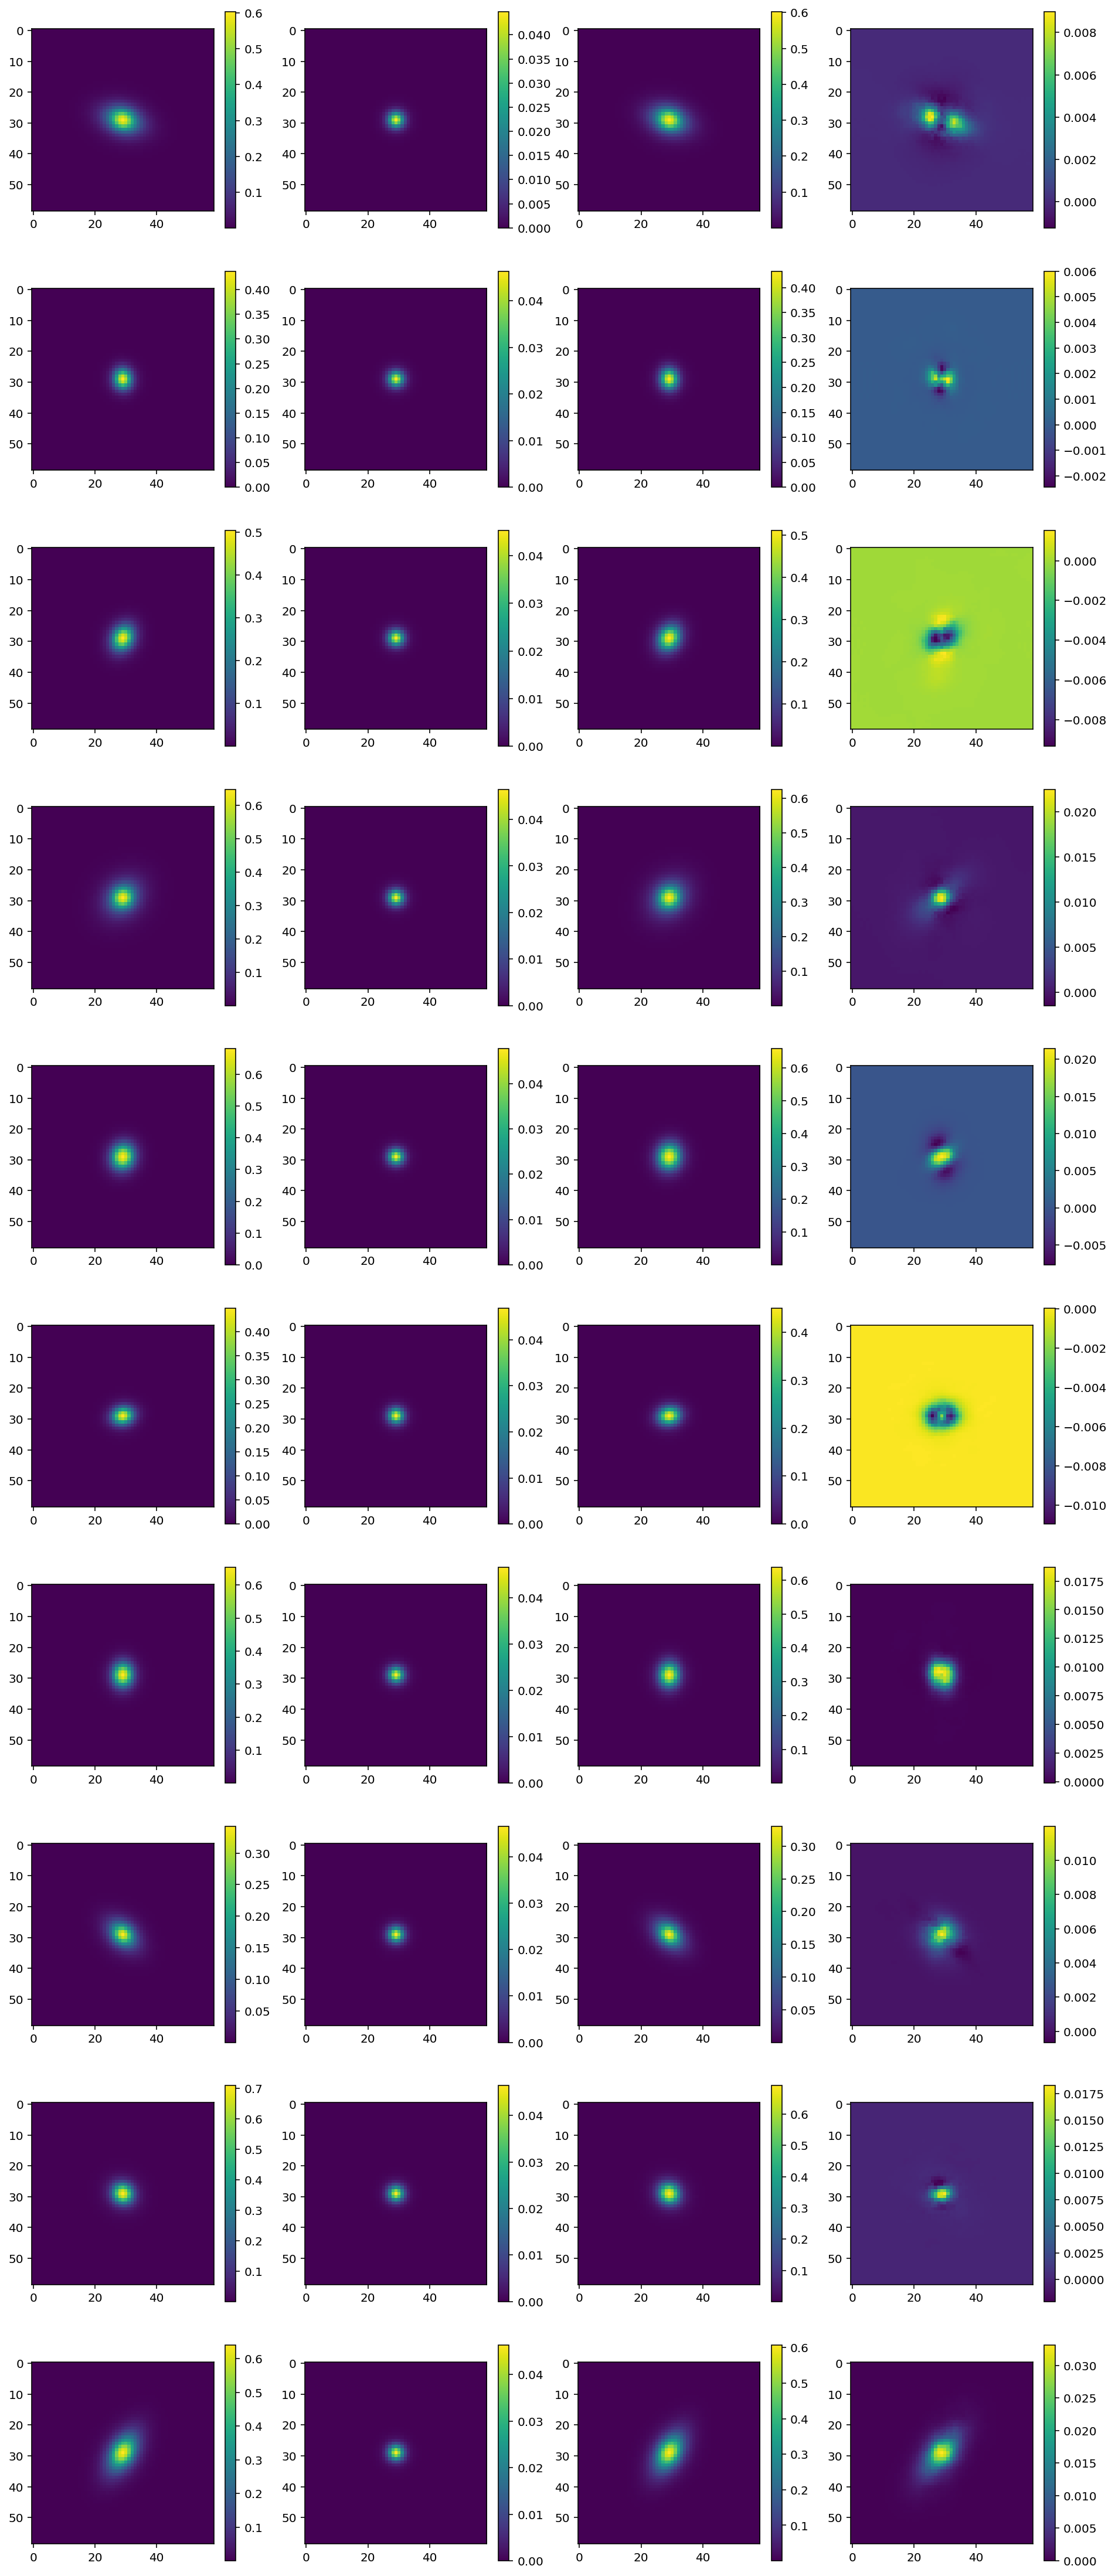

In [17]:
fig, axes = plt.subplots(10,4, figsize = (16, 40))

for i in range (10):
    f1 = axes[i,0].imshow(training_data[0][i,:,:,2])
    f2 = axes[i,1].imshow(training_data[1][i,:,:,2])
    f3 = axes[i,2].imshow(output[i,:,:,2])
    f4 = axes[i,3].imshow(training_data[0][i,:,:,2] - output[i,:,:,2])
    
    fig.colorbar(f1, ax = axes[i,0])
    fig.colorbar(f2, ax = axes[i,1])
    fig.colorbar(f3, ax = axes[i,2])
    fig.colorbar(f4, ax = axes[i,3])
    

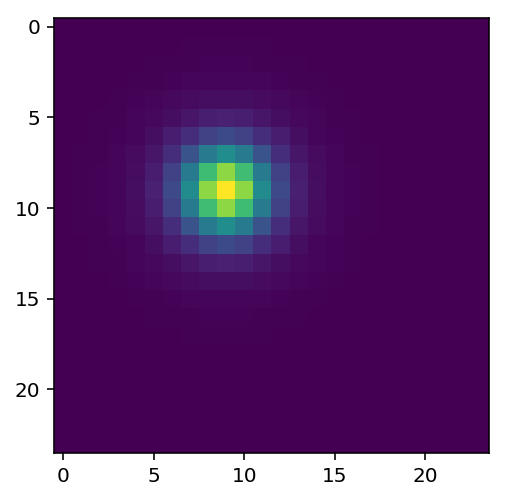

In [19]:
plt.imshow(training_data[1][i,20:44,20:44,2])

## Test without PSF input

In [13]:

#net_2 = tools_for_VAE.model.create_model_wo_ls_peak_pooling_vae(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation='relu', dense_activation='relu')

In [14]:
net_2 = tools_for_VAE.model.create_model_wo_ls_peak_pooling_vae_2(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation='relu', dense_activation='relu')

in cropping


In [15]:
latest = tf.train.latest_checkpoint(path_output)
net_2.load_weights(latest)

In [16]:
net_2.summary()

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_5 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
batch_normalization_2 (BatchNor (None, 59, 59, 6)    24          input_5[0][0]                    
__________________________________________________________________________________________________
conv2d_34 (Conv2D)              (None, 30, 30, 32)   1760        batch_normalization_2[0][0]      
__________________________________________________________________________________________________
p_re_lu_58 (PReLU)              (None, 30, 30, 32)   28800       conv2d_34[0][0]                  
____________________________________________________________________________________________

In [ ]:
images_dir = '/pbs/home/b/barcelin/sps_link/data/dc2_test/'
list_of_samples = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test_24.5_v2/')) if x.startswith(os.path.join(images_dir,'test_24.5_v2/')+'img_noiseless_sample')]#mag_24.5

test_generator = generator.BatchGenerator_dc2_deconv_vae(bands, 
                                    images_dir,
                                    list_of_samples, 
                                    total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='test',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None)

In [ ]:
test = test_generator.__getitem__(3)

training_data = test[0]
training_labels = test[1]

In [19]:
output_2 = net_2([tf.cast(training_data[0], tf.float32), tf.cast(training_data[1], tf.float32)])

In [20]:
output_2 = K.get_value(output_2)

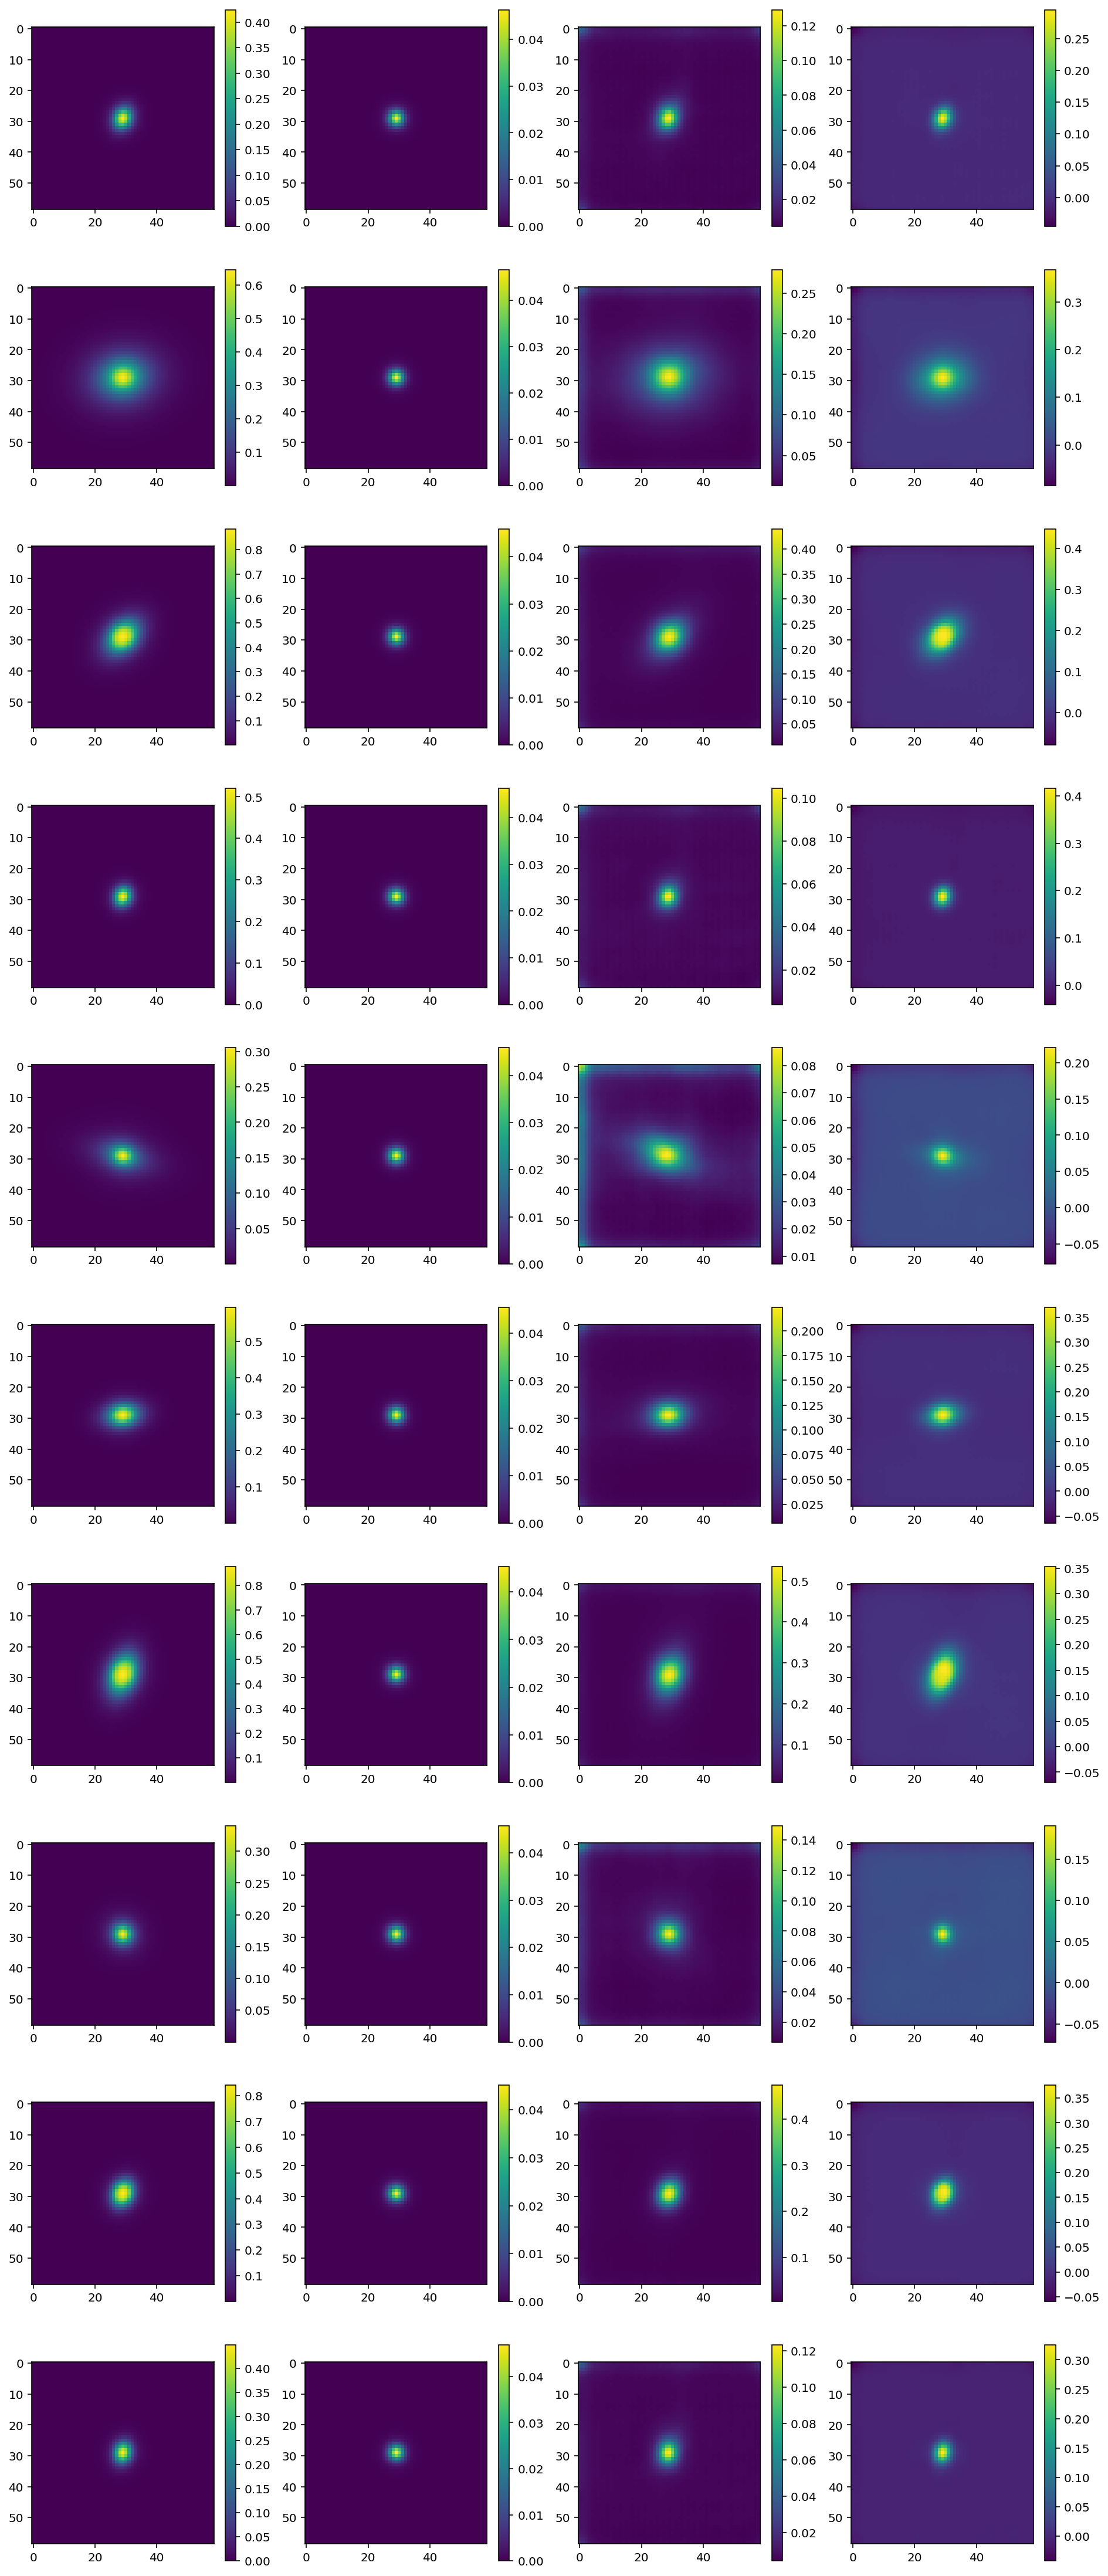

In [21]:
fig, axes = plt.subplots(10,4, figsize = (16, 40))

for i in range (10):
    f1 = axes[i,0].imshow(training_data[0][i,:,:,2])
    f2 = axes[i,1].imshow(training_data[1][i,:,:,2])
    f3 = axes[i,2].imshow(output_2[i,:,:,2])
    f4 = axes[i,3].imshow(training_data[0][i,:,:,2] - output_2[i,:,:,2])
    
    fig.colorbar(f1, ax = axes[i,0])
    fig.colorbar(f2, ax = axes[i,1])
    fig.colorbar(f3, ax = axes[i,2])
    fig.colorbar(f4, ax = axes[i,3])
    